# Notebook 01: Look-Ahead Bias

## Objective

Investigate the impact of look-ahead bias on backtest performance.

Look-ahead bias occurs when future information is inadvertently incorporated into trading decisions.

To demonstrate this effect, two versions of the strategy are compared:

1. Biased implementation using today's signal to trade today's return.
2. Corrected implementation using yesterday's signal to trade today's return.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import total_return,sharpe_ratio,max_drawdown

In [2]:
df=load_data("SPY")
print(df.head())

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.888153  296.906448  294.749706  295.672721  59151200
2020-01-03  294.640045  295.764112  293.442881  293.497711  77709700
2020-01-06  295.764130  295.846374  292.766617  292.885424  55653900
2020-01-07  294.932495  295.672726  294.484681  295.197497  40496400
2020-01-08  296.504425  297.719857  294.877741  295.124476  68296000


In [3]:
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()

df["Signal"] = 0
df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1

df[["Close", "SMA_50", "SMA_200", "Signal"]].tail()

Price,Close,SMA_50,SMA_200,Signal
Ticker,SPY,,,
Date,,,,
2026-06-08,739.219971,715.394399,682.097073,1
2026-06-09,737.049988,717.453599,682.631301,1
2026-06-10,725.429993,719.322799,683.059039,1
2026-06-11,737.760010,721.071199,683.562508,1
2026-06-12,741.750000,722.801399,684.072590,1


In [4]:
df["Returns"] = df["Close"].pct_change()

df["Strategy_Returns"] = (
    df["Signal"].shift(1) * df["Returns"]
)

df[["Returns", "Strategy_Returns"]].head()

Price,Returns,Strategy_Returns
Ticker,,
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.007572,-0.0
2020-01-06,0.003815,0.0
2020-01-07,-0.002812,-0.0
2020-01-08,0.005330,0.0


In [5]:
df["Equity"] = (
    1 + df["Strategy_Returns"]
).cumprod()

df["Market"] = (
    1 + df["Returns"]
).cumprod()

In [8]:
# WRONG (Look-Ahead Bias)
df["Strategy_Returns_Biased"] = (
    df["Signal"] * df["Returns"]
)

df["Equity_Biased"] = (
    1 + df["Strategy_Returns_Biased"].fillna(0)
).cumprod()


# CORRECT
df["Strategy_Returns_Correct"] = (
    df["Signal"].shift(1) * df["Returns"]
)

df["Equity_Correct"] = (
    1 + df["Strategy_Returns_Correct"].fillna(0)
).cumprod()

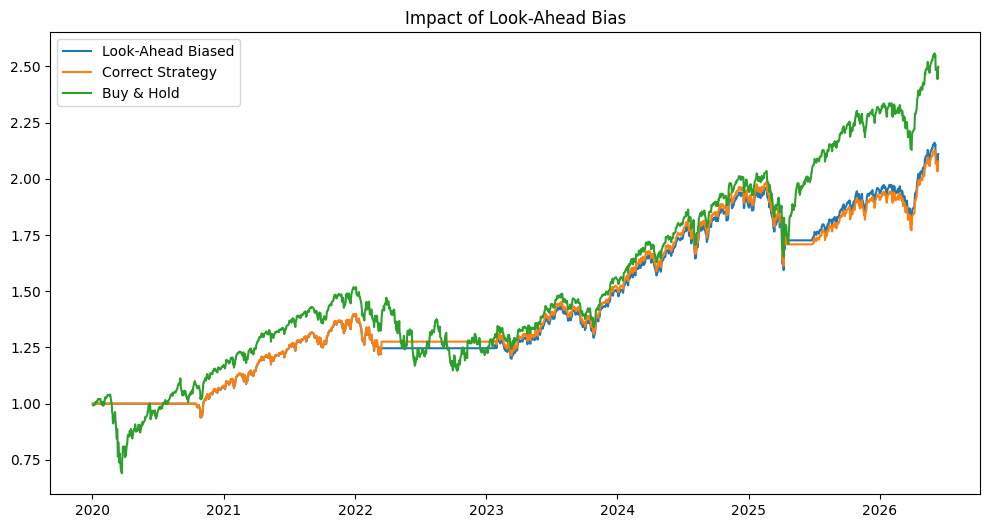

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df["Equity_Biased"],
    label="Look-Ahead Biased"
)

plt.plot(
    df.index,
    df["Equity_Correct"],
    label="Correct Strategy"
)

plt.plot(
    df.index,
    df["Market"],
    label="Buy & Hold"
)

plt.title("Impact of Look-Ahead Bias")

plt.legend()

plt.savefig(
    "../images/lookahead_bias.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
returns = df["Strategy_Returns"].dropna()

print("Total Return:",
      round(total_return(df["Equity"]) * 100, 2), "%")

print("Sharpe Ratio:",
      round(sharpe_ratio(returns), 2))

print("Max Drawdown:",
      round(max_drawdown(df["Equity"]) * 100, 2), "%")

Total Return: 107.86 %
Sharpe Ratio: 0.96
Max Drawdown: -18.76 %


## Results Comparison

| Strategy | Total Return | Sharpe Ratio | Maximum Drawdown |
|-----------|--------------|---------------|-------------------|
| Look-Ahead Biased | 111.04% | 0.98 | -18.76% |
| Look-Ahead Corrected | 107.86% | 0.96 | -18.76% |